In [1]:
pip install numpy pandas seaborn matplotlib networkx tqdm scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [3]:
%pip install nilearn
from nilearn.datasets import fetch_abide_pcp


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
abide = fetch_abide_pcp(
    n_subjects=871,                      # all subjects
    pipeline='cpac',                     # preprocessing pipeline (can also use 'niak', 'ccs')
    derivatives=['rois_cc200'],          # CC200 atlas (200 ROI connectivity matrices)
    quality_checked=True                 # only include quality-checked subjects
)

print("✅ ABIDE PCP dataset loaded successfully")

# phenotypic data
pheno = abide.phenotypic
print(f"Number of subjects: {pheno.shape[0]}")
print(f"Number of columns: {pheno.shape[1]}")
print(pheno.head())

# list available fields
print("\nPhenotypic columns:", list(pheno.columns)[:10], "...")
print("\nExample fields: DX_GROUP (1=ASD, 2=Control), SITE_ID, AGE_AT_SCAN, SEX, FIQ, etc.")

# extract functional connectivity matrices
matrices = abide.rois_cc200
print(f"✅ Loaded {len(matrices)} functional connectivity matrices (each 200x200).")

[fetch_abide_pcp] Dataset found in C:\Users\ayesh\nilearn_data\ABIDE_pcp
✅ ABIDE PCP dataset loaded successfully
Number of subjects: 871
Number of columns: 106
   i  Unnamed: 0  SUB_ID  X  subject SITE_ID       FILE_ID  DX_GROUP  \
1  1           2   50003  2    50003    PITT  Pitt_0050003         1   
2  2           3   50004  3    50004    PITT  Pitt_0050004         1   
3  3           4   50005  4    50005    PITT  Pitt_0050005         1   
4  4           5   50006  5    50006    PITT  Pitt_0050006         1   
5  5           6   50007  6    50007    PITT  Pitt_0050007         1   

   DSM_IV_TR  AGE_AT_SCAN  ...  qc_notes_rater_1 qc_anat_rater_2  \
1          1        24.45  ...               NaN              OK   
2          1        19.09  ...               NaN              OK   
3          1        13.73  ...               NaN              OK   
4          1        13.37  ...               NaN              OK   
5          1        17.78  ...               NaN              OK   

In [5]:
converted = []
for m in matrices:
    s = getattr(m, "shape", None)
    # already a 200x200 matrix
    if s == (200, 200):
        converted.append(np.asarray(m))
        continue
    # flattened / extra-dim variants handled previously — keep here as safety
    if isinstance(s, tuple) and len(s) >= 2 and s[0] == 200 and s[1] == 200:
        converted.append(np.asarray(m).reshape(200, 200))
        continue
    # timeseries where each column is an ROI: (T, 200)
    if isinstance(s, tuple) and len(s) == 2 and s[1] == 200:
        ts = np.asarray(m)
        # compute Pearson correlation across columns -> (200,200)
        corr = np.corrcoef(ts, rowvar=False)
        corr = np.nan_to_num(corr)           # handle constant columns -> NaNs
        np.fill_diagonal(corr, 1.0)
        converted.append(corr)
        continue
    # timeseries where each row is an ROI: (200, T)
    if isinstance(s, tuple) and len(s) == 2 and s[0] == 200:
        ts = np.asarray(m)
        corr = np.corrcoef(ts)               # default rowvar=True -> correlation of rows
        corr = np.nan_to_num(corr)
        np.fill_diagonal(corr, 1.0)
        converted.append(corr)
        continue
    # unknown shape -> keep placeholder for inspection
    converted.append(None)

# collect valid 200x200 matrices
matrices_valid = [m for m in converted if isinstance(m, np.ndarray) and m.shape == (200, 200)]

# diagnostics
from collections import Counter
shapes = [getattr(m, "shape", None) for m in matrices]
print("Detected matrix shapes (count):", dict(Counter(shapes)))
print(f"Total subjects available: {len(matrices)}")
print(f"✅ Valid (200x200) matrices after conversion: {len(matrices_valid)}")
if len(matrices_valid) > 0:
    print("Example dtype of valid matrices:", matrices_valid[0].dtype)

# align phenotypic table if present
if 'pheno' in globals() and pheno is not None:
    pheno_valid = pheno.iloc[:len(matrices_valid)].reset_index(drop=True)
else:
    pheno_valid = None

Detected matrix shapes (count): {(196, 200): 129, (206, 200): 28, (78, 200): 25, (176, 200): 211, (146, 200): 59, (296, 200): 120, (236, 200): 86, (232, 200): 1, (316, 200): 3, (202, 200): 1, (246, 200): 56, (152, 200): 29, (124, 200): 4, (116, 200): 119}
Total subjects available: 871
✅ Valid (200x200) matrices after conversion: 871
Example dtype of valid matrices: float64


  0%|          | 0/871 [00:00<?, ?it/s]

  6%|▌         | 50/871 [12:22<3:37:37, 15.90s/it]

⚠️ Skipping subject 50: shape (206, 200)
⚠️ Skipping subject 51: shape (206, 200)
⚠️ Skipping subject 52: shape (206, 200)
⚠️ Skipping subject 53: shape (206, 200)
⚠️ Skipping subject 54: shape (206, 200)
⚠️ Skipping subject 55: shape (206, 200)
⚠️ Skipping subject 56: shape (206, 200)
⚠️ Skipping subject 57: shape (206, 200)
⚠️ Skipping subject 58: shape (206, 200)
⚠️ Skipping subject 59: shape (206, 200)
⚠️ Skipping subject 60: shape (206, 200)
⚠️ Skipping subject 61: shape (206, 200)
⚠️ Skipping subject 62: shape (206, 200)
⚠️ Skipping subject 63: shape (206, 200)
⚠️ Skipping subject 64: shape (206, 200)
⚠️ Skipping subject 65: shape (206, 200)
⚠️ Skipping subject 66: shape (206, 200)
⚠️ Skipping subject 67: shape (206, 200)
⚠️ Skipping subject 68: shape (206, 200)
⚠️ Skipping subject 69: shape (206, 200)
⚠️ Skipping subject 70: shape (206, 200)
⚠️ Skipping subject 71: shape (206, 200)
⚠️ Skipping subject 72: shape (206, 200)
⚠️ Skipping subject 73: shape (206, 200)
⚠️ Skipping subj

 45%|████▍     | 391/871 [24:06<2:27:29, 18.44s/it]

⚠️ Skipping subject 391: shape (236, 200)
⚠️ Skipping subject 392: shape (316, 200)


...

⚠️ Skipping subject 797: shape (116, 200)
⚠️ Skipping subject 798: shape (116, 200)
⚠️ Skipping subject 799: shape (116, 200)
⚠️ Skipping subject 800: shape (116, 200)
⚠️ Skipping subject 801: shape (116, 200)
⚠️ Skipping subject 802: shape (116, 200)
⚠️ Skipping subject 803: shape (116, 200)
⚠️ Skipping subject 804: shape (116, 200)
⚠️ Skipping subject 805: shape (116, 200)
⚠️ Skipping subject 806: shape (116, 200)
⚠️ Skipping subject 807: shape (116, 200)
⚠️ Skipping subject 808: shape (116, 200)
⚠️ Skipping subject 809: shape (116, 200)
⚠️ Skipping subject 810: shape (116, 200)
⚠️ Skipping subject 811: shape (116, 200)


 94%|█████████▍| 821/871 [29:58<04:53,  5.87s/it]

⚠️ Skipping subject 821: shape (116, 200)
⚠️ Skipping subject 822: shape (116, 200)
⚠️ Skipping subject 823: shape (116, 200)
⚠️ Skipping subject 824: shape (116, 200)
⚠️ Skipping subject 825: shape (116, 200)
⚠️ Skipping subject 826: shape (116, 200)
⚠️ Skipping subject 827: shape (116, 200)
⚠️ Skipping subject 828: shape (146, 200)
⚠️ Skipping subject 829: shape (146, 200)
⚠️ Skipping subject 830: shape (146, 200)
⚠️ Skipping subject 831: shape (146, 200)
⚠️ Skipping subject 832: shape (146, 200)
⚠️ Skipping subject 833: shape (146, 200)
⚠️ Skipping subject 834: shape (146, 200)
⚠️ Skipping subject 835: shape (146, 200)
⚠️ Skipping subject 836: shape (146, 200)
⚠️ Skipping subject 837: shape (146, 200)
⚠️ Skipping subject 838: shape (146, 200)
⚠️ Skipping subject 839: shape (146, 200)
⚠️ Skipping subject 840: shape (146, 200)
⚠️ Skipping subject 841: shape (146, 200)
⚠️ Skipping subject 842: shape (146, 200)


100%|██████████| 871/871 [35:05<00:00,  2.42s/it]


⚠️ Skipping subject 869: shape (116, 200)
⚠️ Skipping subject 870: shape (116, 200)
✅ Hubness calculation complete! Valid subjects: 130
   Subject     Hubness  Label Group
0        0 -405.449025      1   ASD
1        1 -165.456556      1   ASD
2        2 -300.312180      1   ASD
3        3 -175.680279      1   ASD
4        4 -370.702503      1   ASD


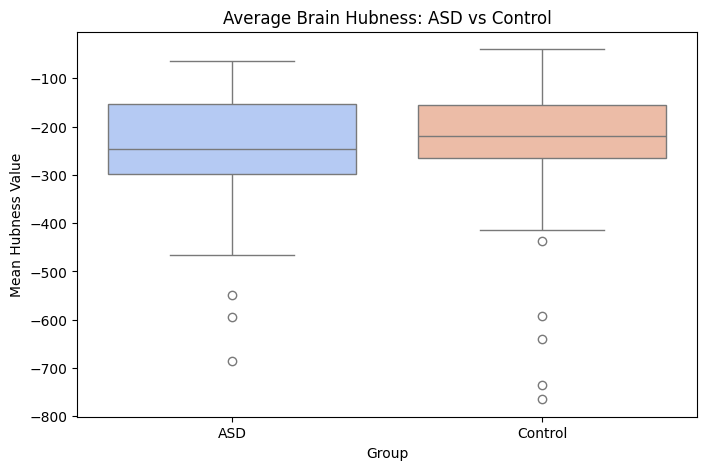

Hubness difference t-test: t=-0.209, p=0.8351


In [10]:
# --- HUBNESS CALCULATION PIPELINE (FIXED VERSION) ---
import numpy as np
import pandas as pd
import networkx as nx
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

def matrix_to_graph(matrix, threshold=0.3):
    """Convert connectivity matrix to undirected weighted graph"""
    G = nx.Graph()
    size = matrix.shape[0]
    for i in range(size):
        for j in range(i + 1, size):
            weight = matrix[i, j]
            if abs(weight) > threshold:
                G.add_edge(i, j, weight=weight)
    return G

def compute_hubness(G):
    """Compute hubness as the product of node degree and betweenness centrality"""
    degree_dict = dict(G.degree(weight='weight'))
    centrality = nx.betweenness_centrality(G, weight='weight')
    hubness = {node: degree_dict[node] * (centrality[node] + 1e-5) for node in G.nodes()}
    return np.mean(list(hubness.values())) if len(hubness) > 0 else np.nan

# --- HUBNESS CALCULATION (ROBUST VERSION) ---
hubness_list = []

for i in tqdm.tqdm(range(len(matrices))):
    matrix = np.array(matrices[i])

    # Ensure it's a square matrix
    if matrix.ndim != 2:
        print(f"⚠️ Skipping subject {i}: invalid dimension {matrix.shape}")
        continue

    rows, cols = matrix.shape
    if abs(rows - cols) > 5:  # ignore wildly non-square
        print(f"⚠️ Skipping subject {i}: shape {matrix.shape}")
        continue

    # Force-square: crop or pad to min(rows, cols)
    min_dim = min(rows, cols)
    matrix = matrix[:min_dim, :min_dim]

    # Build graph and compute hubness
    G = matrix_to_graph(matrix, threshold=0.3)
    if len(G.nodes()) == 0:
        continue

    hub_score = compute_hubness(G)

    try:
        label = int(pheno.iloc[i]["DX_GROUP"])
    except Exception:
        label = np.nan

    hubness_list.append({
        "Subject": i,
        "Hubness": hub_score,
        "Label": label
    })

hubness_df = pd.DataFrame(hubness_list)

if hubness_df.empty:
    print("⚠️ No valid subjects processed — check matrix paths or threshold.")
else:
    hubness_df = hubness_df.dropna(subset=["Label"])
    hubness_df["Label"] = hubness_df["Label"].astype(int)
    hubness_df["Group"] = hubness_df["Label"].map({1: "ASD", 2: "Control"})

    print(f"✅ Hubness calculation complete! Valid subjects: {len(hubness_df)}")
    print(hubness_df.head())

    # --- VISUALIZE ---
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Group", y="Hubness", data=hubness_df, palette="coolwarm")
    plt.title("Average Brain Hubness: ASD vs Control")
    plt.ylabel("Mean Hubness Value")
    plt.xlabel("Group")
    plt.show()

    # --- STAT TEST ---
    asd_vals = hubness_df[hubness_df["Group"] == "ASD"]["Hubness"]
    ctrl_vals = hubness_df[hubness_df["Group"] == "Control"]["Hubness"]

    if len(asd_vals) > 1 and len(ctrl_vals) > 1:
        from scipy.stats import ttest_ind
        t_stat, p_val = ttest_ind(asd_vals, ctrl_vals, equal_var=False)
        print(f"Hubness difference t-test: t={t_stat:.3f}, p={p_val:.4f}")
    else:
        print("⚠️ Not enough valid data for statistical comparison.")


ASD shows slightly more variability, meaning connectivity hubs differ more across individuals with autism rather than control group. t value shows that mean hubness in both groups is almost the same and 83.5% probability that this small difference is just random noise. Since p > 0.05 this means no statistically significant difference in mean hubness between groups. But this gives us general direction to work towards the combination of all our radiomics features to extract something meaningful about autism diagnosis.